In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
# load dataset

In [3]:
df = pd.read_csv("StudentsPerformance.csv")
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


# data preprocessing 

In [4]:
df.shape

(1000, 8)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 103.5 KB


check missing value

In [6]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [7]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


# check duplicates


In [8]:
df.duplicated().sum()

np.int64(0)

# Observation

no duplicates no missing value

In [9]:
df.dtypes

gender                           str
race/ethnicity                   str
parental level of education      str
lunch                            str
test preparation course          str
math score                     int64
reading score                  int64
writing score                  int64
dtype: object

# import labelencoder 
 The dataset contains both categorical and numerical features.
 Categorical columns need encoding before model training.

In [10]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])
df


C:\Users\prime\AppData\Local\Temp\ipykernel_9528\3595544648.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,0,1,1,1,1,72,72,74
1,0,2,4,1,0,69,90,88
2,0,1,3,1,1,90,95,93
3,1,0,0,0,1,47,57,44
4,1,2,4,1,1,76,78,75
...,...,...,...,...,...,...,...,...
995,0,4,3,1,0,88,99,95
996,1,2,2,0,1,62,55,55
997,0,2,2,0,0,59,71,65
998,0,3,4,1,0,68,78,77


 Categorical features were converted into numerical values using Label Encoding.
 The dataset is now ready for machine learning preprocessing steps.

# EDA

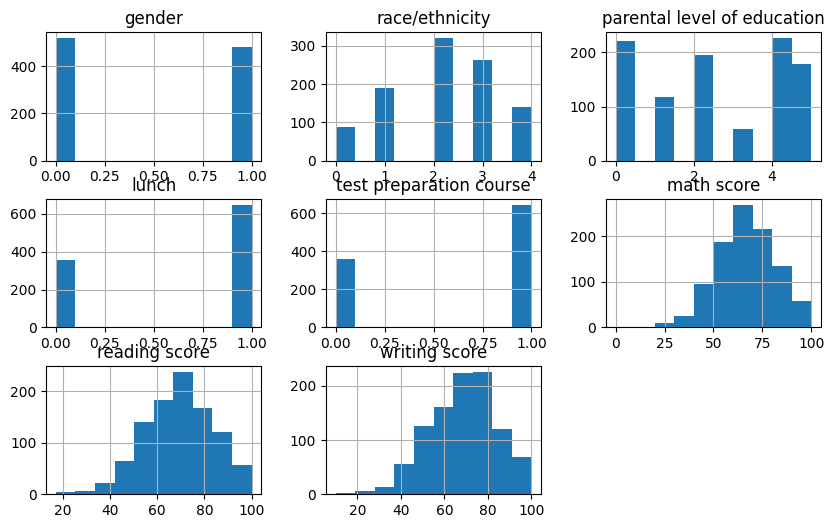

In [11]:
df.hist(figsize=(10,6))
plt.show()

# check outliers

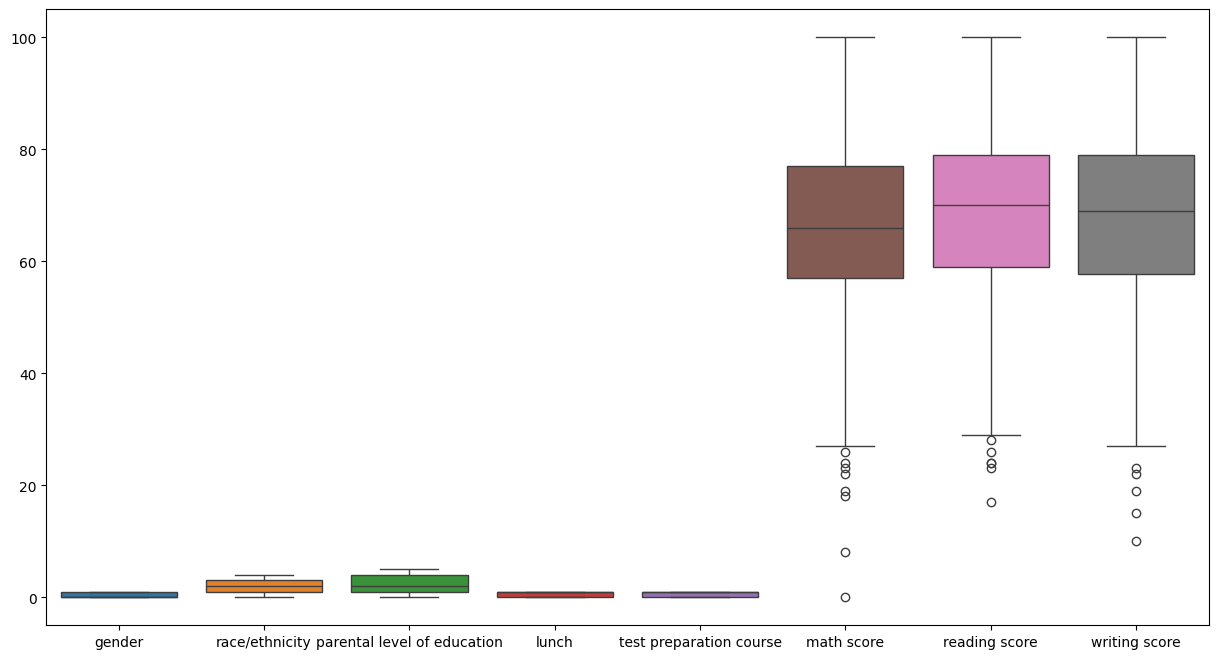

In [12]:
plt.figure(figsize=(15,8))
sns.boxplot(data=df)
plt.show()

In [13]:
# Outliers remove using IQR

cols = ['math score', 'reading score', 'writing score']
for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower) & (df[col] <= upper)]

print(df.shape)

(986, 8)


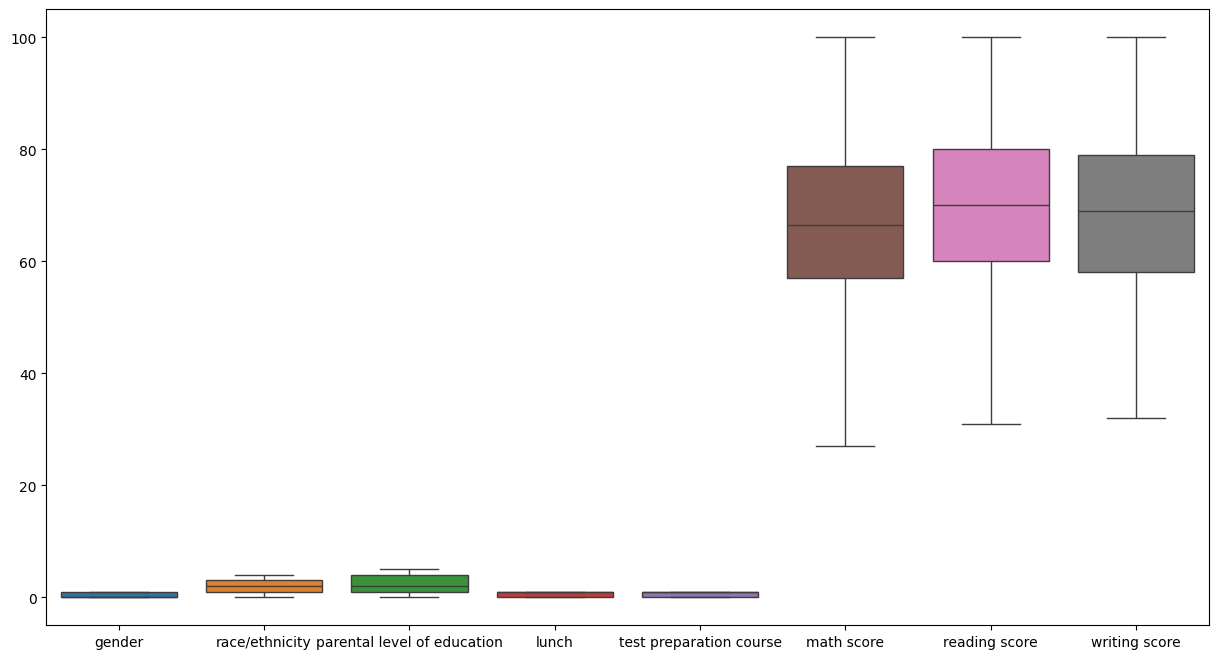

In [14]:
plt.figure(figsize=(15,8))
sns.boxplot(data=df)
plt.show()

# Observation 
there is some outliers are present in data sa then handle with IQR methods 

# scatterplot checking

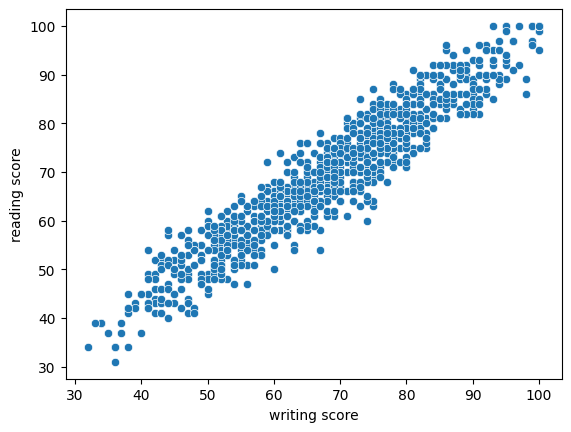

In [15]:
sns.scatterplot(x='writing score', y='reading score', data=df)
plt.show()

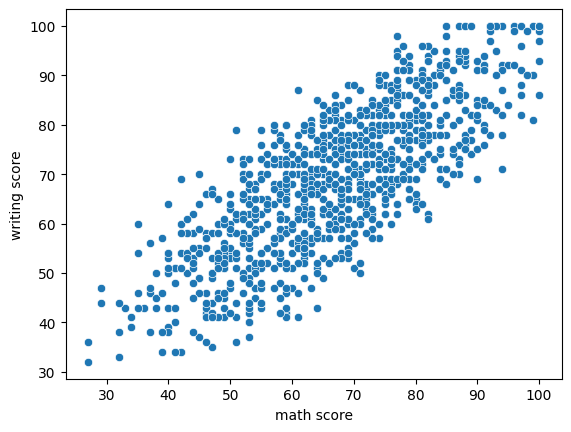

In [16]:
sns.scatterplot(x='math score', y='writing score', data=df)
plt.show()

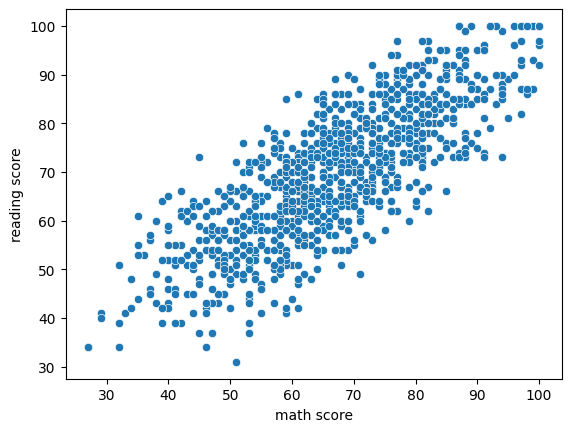

In [17]:
sns.scatterplot(x='math score', y='reading score', data=df)
plt.show()

# Observation 
The scatterplots show a strong positive correlation among math, reading, and writing scores. Students with high marks in one subject generally achieve high marks in the others as well.


#  heatmaps  correlation 

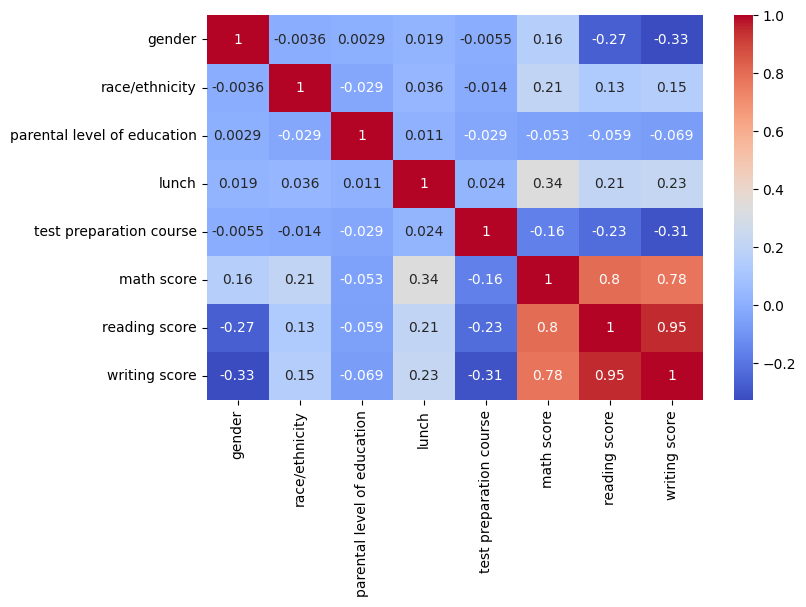

In [18]:
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

# Observation:
Reading and writing scores have a strong positive correlation.
Math score is also positively correlated with reading and writing scores.

# Feature Selection

In [19]:
X = df.drop('math score', axis=1)
y = df['math score']

# Train-Test Split

In [20]:
from sklearn.model_selection import train_test_split


In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# Feature Scalling

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# Observation:
Feature scaling was applied to the training and testing data using StandardScaler.
The features are now standardized for model training.


# Linear Regression Model

In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [24]:
# Model Create
lr_model = LinearRegression()

# Train Model
lr_model.fit(X_train, y_train)

# Predictions
y_pred_lr = lr_model.predict(X_test)

# Evaluation
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print(" Linear Regression")
print("MSE:", mse_lr)
print("R2 Score:", r2_lr)

 Linear Regression
MSE: 32.740124146904144
R2 Score: 0.8492354994926652



# Observation:
 The Random Forest Regressor achieved an R² score of approximately 82%.
 The model shows strong prediction performance on the dataset.

# Decision Tree

In [25]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

dt_model = DecisionTreeRegressor()

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

# Save values in variables
mse_dt = mean_squared_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print("MSE:", mse_dt)
print("R2 Score:", r2_dt)

MSE: 73.0
R2 Score: 0.6638434085450425



# Observation:
 The model achieved an R² score of approximately 70%.
 The model shows good prediction performance on the dataset.

In [26]:
print("Linear Regression")
print("MSE :", mse_lr)
print("R2 Score :", r2_lr)
print("Decision Tree")
print("MSE :", mse_dt)
print("R2 Score :", r2_dt)

Linear Regression
MSE : 32.740124146904144
R2 Score : 0.8492354994926652
Decision Tree
MSE : 73.0
R2 Score : 0.6638434085450425


In [27]:
df.to_csv("cleaned_students_data.csv", index=False)
print("our clean dataset 'leaned_students_data.csv' is saved!")

our clean dataset 'leaned_students_data.csv' is saved!


In [28]:
import pickle

# Decision Tree model save
pickle.dump(r2_dt, open("decision_tree_model.pkl", "wb"))

# Logistic Regression model save
pickle.dump(r2_lr,open("logistic_regression_model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pk1", 'wb'))